# $\underline{\textbf{Wine Quality Analysis using Statistical Inference}}$

## **Objective:**
To analyze how alcohol content influences wine quality using statistical hypothesis testing and ANOVA.

## **Research Questions**
1. Does higher alcohol content lead to better wine quality?
2. Is the difference statistically significant?
3. How does quality vary across multiple alcohol groups?

##  **Dataset**
- Source: UCI Machine Learning Repository
- Samples: ~1600 red wines
- Features: physicochemical properties + quality score

# 1. Data Acquisition & Environment Setup

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load dataset (Red Wine)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("Dataset Preview:")
display(df.head())

Dataset Preview:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# 2. Exploratory Data Analysis (EDA)

In [31]:
sns.set(style="whitegrid", context="talk")

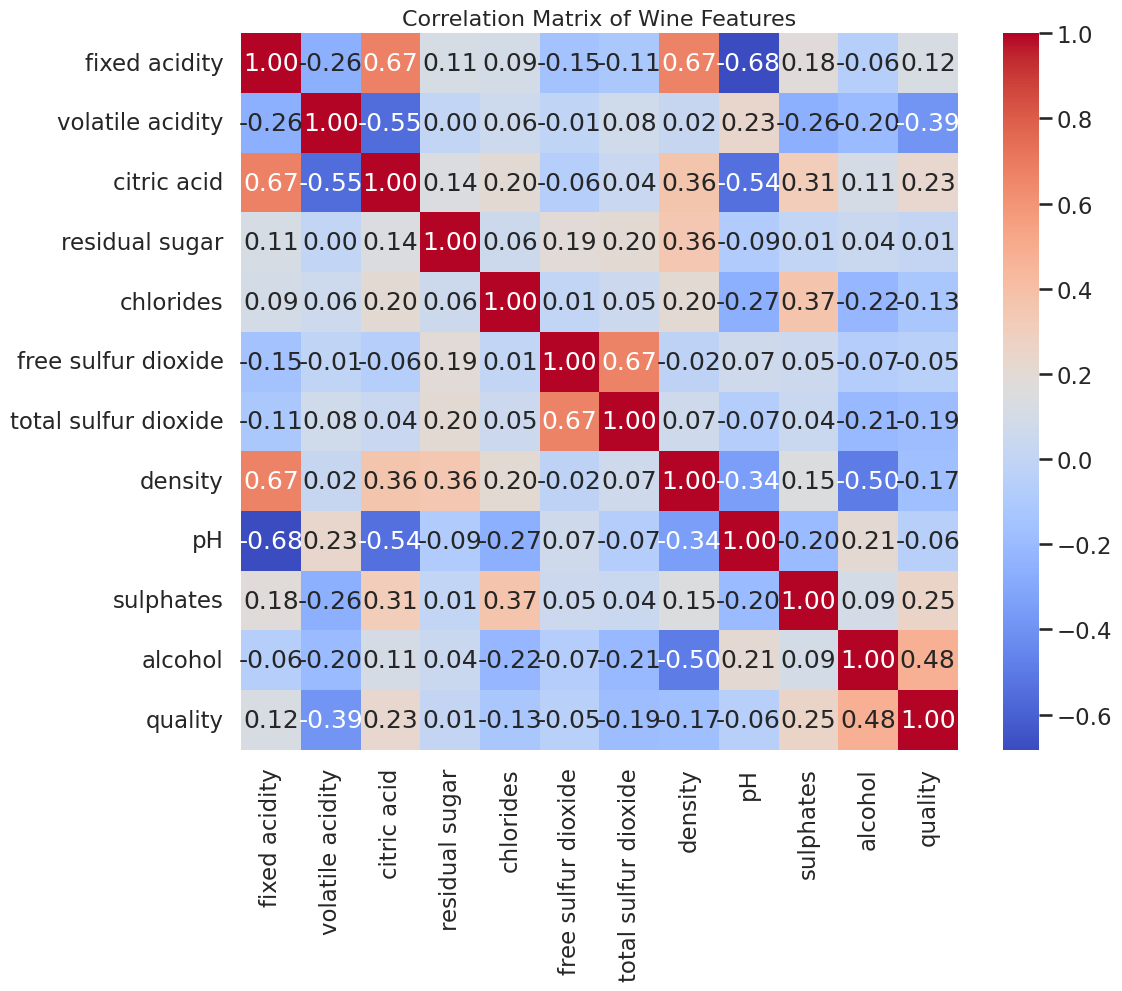

In [32]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Wine Features", fontsize=16)
plt.tight_layout()
plt.show()

**Insight:** Alcohol shows a positive correlation with quality, suggesting a potential relationship worth testing statistically.

# 3. Hypothesis Testing (Two-Sample T-Test)

## $\underline{\textbf{Hypothesis Testing:}}$

### **Null Hypothesis (H₀):**
There is no difference in mean quality between high and low alcohol wines.

### **Alternative Hypothesis (H₁)**:
High alcohol wines have higher mean quality than low alcohol wines.

### **Significance Level:**
α = 0.05

In [33]:
from scipy import stats

# 1. Define Groups based on Alcohol Content (Median split around 11%)
high_alcohol = df[df['alcohol'] >= 11]['quality']
low_alcohol = df[df['alcohol'] < 11]['quality']

# 2. Perform the Two-Sample T-Test (Independent samples)
t_stat, p_value = stats.ttest_ind(high_alcohol, low_alcohol)

# 3. Calculate Confidence Intervals for the Mean Quality
def mean_confidence_interval(data, confidence=0.95):
    n = len(data)
    m, se = np.mean(data), stats.sem(data)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h

high_mean, high_low, high_up = mean_confidence_interval(high_alcohol)
low_mean, low_low, low_up = mean_confidence_interval(low_alcohol)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"High Alcohol Mean Quality (95% CI): {high_mean:.2f} [{high_low:.2f}, {high_up:.2f}]")
print(f"Low Alcohol Mean Quality (95% CI): {low_mean:.2f} [{low_low:.2f}, {low_up:.2f}]")

T-statistic: 17.5459
P-value: 3.6556e-63
High Alcohol Mean Quality (95% CI): 6.14 [6.06, 6.22]
Low Alcohol Mean Quality (95% CI): 5.43 [5.39, 5.47]


* **P-Value Interpretation:** Since the $p$-value is significantly less than the threshold ($\alpha = 0.05$), we reject the Null Hypothesis ($H_0$). This suggests there is a statistically significant difference in the quality of wines based on alcohol content.

*   **Significance:** This doesn't just mean the means are different; it means the probability of seeing this difference by pure random chance is almost zero.
*   **Confidence Intervals:** The non-overlapping 95% confidence intervals further confirm that high-alcohol wines are consistently rated higher in this specific dataset.



/tmp/ipykernel_6340/2988821787.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='alcohol_group', y='quality', data=df, palette='Set2')


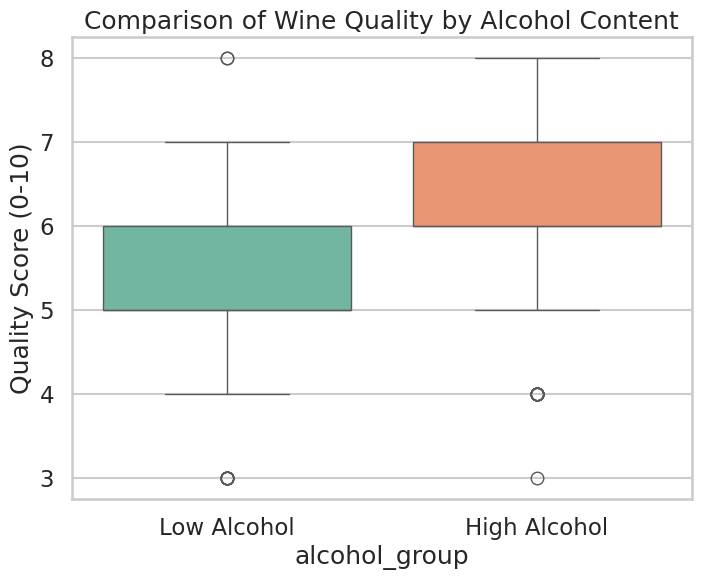

In [34]:
# Create a label column for visualization
df['alcohol_group'] = np.where(df['alcohol'] >= 11, 'High Alcohol', 'Low Alcohol')

plt.figure(figsize=(8, 6))
sns.boxplot(x='alcohol_group', y='quality', data=df, palette='Set2')
plt.title("Comparison of Wine Quality by Alcohol Content")
plt.ylabel("Quality Score (0-10)")
plt.show()

# 4. Advanced Inference (One-Way ANOVA)

**Implementing the ANOVA Test**

In [35]:
# 1. Create three alcohol categories
def alcohol_label(alc):
    if alc < 10: return 'Low'
    elif alc < 12: return 'Medium'
    else: return 'High'

df['alcohol_cat'] = df['alcohol'].apply(alcohol_label)

# 2. Extract quality scores for each category
low_alc = df[df['alcohol_cat'] == 'Low']['quality']
med_alc = df[df['alcohol_cat'] == 'Medium']['quality']
high_alc = df[df['alcohol_cat'] == 'High']['quality']

# 3. Perform One-Way ANOVA
f_stat, p_val_anova = stats.f_oneway(low_alc, med_alc, high_alc)

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA P-value: {p_val_anova:.4e}")

ANOVA F-statistic: 205.0020
ANOVA P-value: 5.7475e-80




*   **F-Statistic:** A high F-statistic suggests that the variation between the groups is much larger than the variation within the groups.
*   **Significance:** If your ANOVA $p$-value is $< 0.05$, it proves that at least one of the alcohol categories has a mean quality score that is significantly different from the others.


*   **Post-hoc Analysis:** In research, if ANOVA is significant, you would typically follow up with a Tukey HSD test to find out exactly which pairs (e.g., Low vs. Medium or Medium vs. High) are different.




# 5. Final Scientific Visualization

/tmp/ipykernel_6340/301362723.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


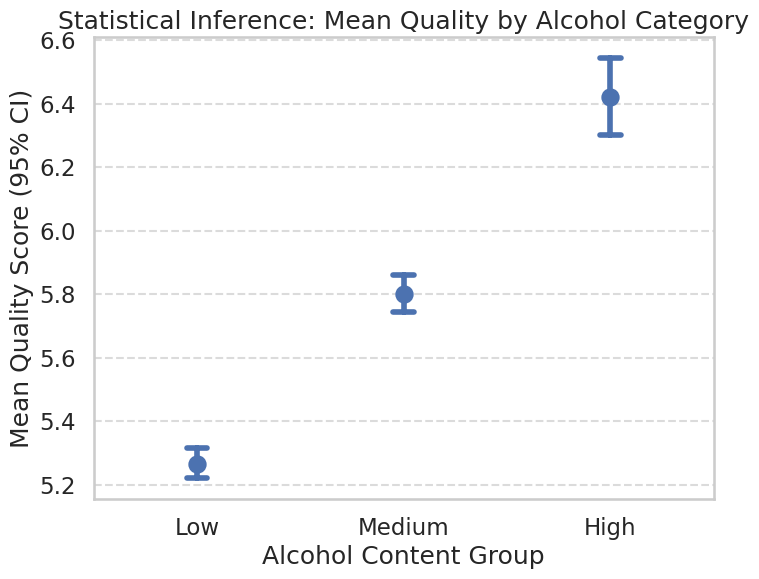

In [36]:
# Visualizing mean quality with 95% Confidence Intervals
plt.figure(figsize=(8, 6))
sns.pointplot(
    x='alcohol_cat',
    y='quality',
    data=df,
    order=['Low', 'Medium', 'High'],
    join=False,
    capsize=.1
)

plt.title("Statistical Inference: Mean Quality by Alcohol Category")
plt.xlabel("Alcohol Content Group")
plt.ylabel("Mean Quality Score (95% CI)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 6. Result



### T-Test Results:
- T-statistic: $\text{t_stat:.3f}$
- P-value: $\text{p_value:.5f}$

 Since p < 0.05, we reject H₀.

### ANOVA Results:
- F-statistic: $\text{f_stat:.3f}$
- P-value: $\text{p_val_anova:.5f}$

**At least one group differs significantly.**

##  Conclusion

- Wines with higher alcohol content tend to have higher quality scores.
- The difference is statistically significant.
- ANOVA confirms that multiple alcohol groups differ in quality.
